# This notebook documents the impact assessment of AIACHNE work on the $^{252}$Cf(sf) PFNS evaluation

In [2]:
# loading python specific codes
from numpy import array, loadtxt, zeros, shape,arange, sqrt, exp, ones, sinh, interp
import importlib
import os
from scipy.optimize import curve_fit
from os import rename
import matplotlib.pyplot as plt
%matplotlib inline 

In [3]:
homedir = os.getcwd() +'/'

In [4]:
cd ../../../src

/Users/dneudecker/Documents/Codes/ARIADNE-github/src


In [5]:
# Loading ARIADNE evaluation code
import EvaluateGLSPFNS as Eval
importlib.reload(Eval)

<module 'EvaluateGLSPFNS' from '/Users/dneudecker/Documents/Codes/ARIADNE-github/src/EvaluateGLSPFNS.py'>

In [6]:
def norm(E,PFNSeval,Eexp,PFNSexp):
    from numpy import interp
    
    DataMod_int = array(interp(Eexp,E,PFNSeval))

    n1 = 0; n2 = 0
    for index1 in arange(0,max(shape(Eexp))-1):
        n1 = n1+0.5*(DataMod_int[index1]+DataMod_int[index1+1])*(Eexp[index1+1]-Eexp[index1])
        n2 = n2+0.5*(PFNSexp[index1]+PFNSexp[index1+1])*(Eexp[index1+1]-Eexp[index1])
    print('Normalization factor:', n1/n2)
    
    return (n1/n2)

In [7]:
def maxwt(E,T):
    pi = 3.14159265359
    
    maxwt = zeros(max(shape(E)),dtype=float)
    for index in arange(0,max(shape(E))):
        maxwt[index] = sqrt(E[index])*exp(-E[index]/T)*(2./sqrt(pi)/sqrt(T)/T)
                     
    return maxwt

## Evaluate before knowing anything from AI/ML of AIACHNE project (LA-UR-25-30840, Figs. 4 and 5):
- Experimental database starts from experimental database before AI/ ML knowledge: DataBase_ForImpactAssessment_BeforeAIMLknowledge.json
- The data have the following LA-UR number LA-UR-25-31736.
- Prior: uninformed prior.
- PPP: on   

------------------------------------
Experiments included in evaluation:
['Bao', 'Tang', 'Fan', 'Cao']
['Blain', 'Daskalakis', 'Block', 'Danon']
['Blain', 'Daskalakis', 'Block', 'Danon']
['Blinov', 'Vitenko', 'Tuz', 'Kazarinov', 'Krisyuk']
['Blinov', 'Vitenko', 'Yurevich']
['Blinov', 'Vitenko', 'Yurevich']
['Blinov', 'Vitenko', 'Yurevich']
['Blinov', 'Vitenko', 'Yurevich']
['Bottger', 'Klein', 'Chalupka', 'Strohmaier']
['Boldeman', 'Clancy', 'Culley']
['Boldeman', 'Clancy', 'Culley']
['Boytsov', 'Starostov']
['Boytsov', 'Starostov']
['Boytsov', 'Starostov']
['A.Chalupka', 'L.Malek', 'S.Tagesen', 'R.Boettger']
['Knitter', 'Paulsen', 'Liskien', 'Islam']
['Knitter', 'Paulsen', 'Liskien', 'Islam']
['N.V.Kornilov']
['A.Lajtai', 'P.P.Dyachenko', 'V.N.Kononov', 'E.A.Seregina']
['Maerten', 'Richter', 'Seeliger', 'Fromm', 'Boettger', 'Klein']
['Maerten', 'Richter', 'Seeliger', 'Fromm', 'Boettger', 'Klein']
['Poenitz', 'Tamura']
------------------------------------

 All experimental data within

['/Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Cf-252/PFNS_EvaluationImpactAssessment/Eval_MvUncCf-2520,fnubar-promptGLS.dat',
 '/Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Cf-252/PFNS_EvaluationImpactAssessment/Eval_CorCf-2520,fnubar-promptGLS.dat']

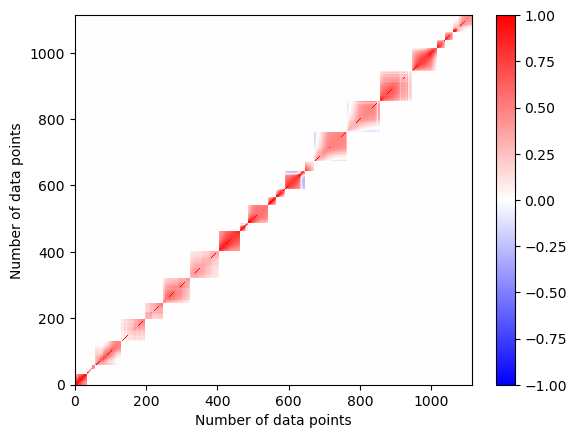

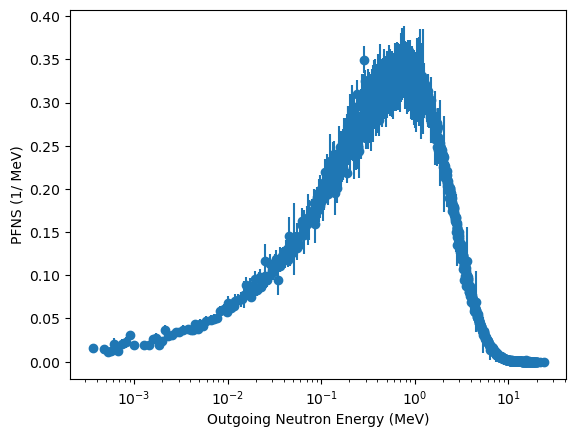

In [9]:
Data = homedir+'DataBase_ForImpactAssessment_BeforeAIMLknowledge.json'
ExpInput = {'Code':"ARIADNE",'ReadOption':'json',\
              'Data':Data}
PriorInput = {'general_info': {'name': 'VIII0_noninformative',\
                               'isotope': array(['Cf-252']),\
                              'quantity': array(['nubar-prompt']), 'reaction':  array(['0,f'])},\
              'Data':{'mv':array([homedir+'PriorMVCf252PFNS_extendedgrid.dat']),\
              'cor':array([homedir+'PriorCorCf252PFNS_extendedgrid.dat'])}}


Eval.Evaluate(ExpInput,PriorInput,homedir,CommonGrid=False,PPPCorrection=True,Plot=False,MaxwRatioEval=False,LogEval=False,OutputFormat="ARIADNEtxt")



In [10]:
rename(homedir+'Eval_MvUncCf-2520,fnubar-promptGLS.dat',homedir+'Eval_MvUncCf252PFNS_BeforeAIACHNEKnowledgePointwise_Final.dat')
rename(homedir+'Eval_CorCf-2520,fnubar-promptGLS.dat',homedir+'Eval_CorCf252PFNS_BeforeAIACHNEKnowledgePointwise_Final.dat')

## Evaluate before knowing anything from AI/ML of AIACHNE project (LA-UR-25-30840, Fig. 4) - removed Knitter data:
- Experimental database starts from experimental database before AI/ ML knowledge: DataBase_ForImpactAssessment_BeforeAIMLknowledge_noKnitter.json which is DataBase_ForImpactAssessment_BeforeAIMLknowledge.json minus Knitter data.
- The data have the following LA-UR number LA-UR-25-31736.
- Prior: uninformed prior.
- PPP: on   

------------------------------------
Experiments included in evaluation:
['Bao', 'Tang', 'Fan', 'Cao']
['Blain', 'Daskalakis', 'Block', 'Danon']
['Blain', 'Daskalakis', 'Block', 'Danon']
['Blinov', 'Vitenko', 'Tuz', 'Kazarinov', 'Krisyuk']
['Blinov', 'Vitenko', 'Yurevich']
['Blinov', 'Vitenko', 'Yurevich']
['Blinov', 'Vitenko', 'Yurevich']
['Blinov', 'Vitenko', 'Yurevich']
['Bottger', 'Klein', 'Chalupka', 'Strohmaier']
['Boldeman', 'Clancy', 'Culley']
['Boldeman', 'Clancy', 'Culley']
['Boytsov', 'Starostov']
['Boytsov', 'Starostov']
['Boytsov', 'Starostov']
['A.Chalupka', 'L.Malek', 'S.Tagesen', 'R.Boettger']
['N.V.Kornilov']
['A.Lajtai', 'P.P.Dyachenko', 'V.N.Kononov', 'E.A.Seregina']
['Maerten', 'Richter', 'Seeliger', 'Fromm', 'Boettger', 'Klein']
['Maerten', 'Richter', 'Seeliger', 'Fromm', 'Boettger', 'Klein']
['Poenitz', 'Tamura']
------------------------------------

 All experimental data within prior grid.
-------------------------------------------
PPP execution, deviation of p

['/Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Cf-252/PFNS_EvaluationImpactAssessment/Eval_MvUncCf-2520,fnubar-promptGLS.dat',
 '/Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Cf-252/PFNS_EvaluationImpactAssessment/Eval_CorCf-2520,fnubar-promptGLS.dat']

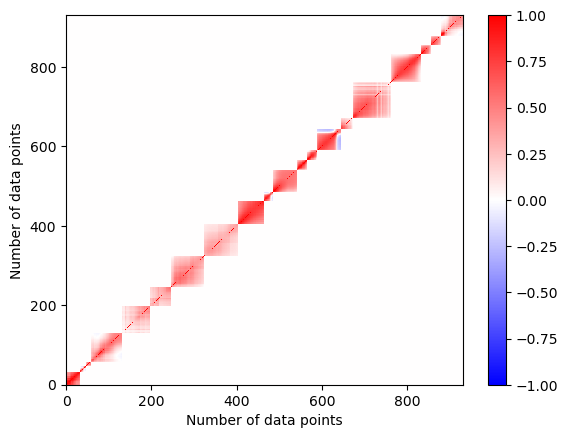

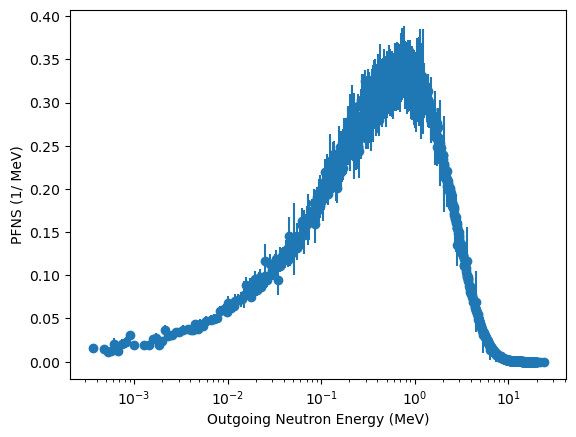

In [12]:
Data = homedir+'DataBase_ForImpactAssessment_BeforeAIMLknowledge_noKnitter.json'
ExpInput = {'Code':"ARIADNE",'ReadOption':'json',\
              'Data':Data}
PriorInput = {'general_info': {'name': 'VIII0_noninformative',\
                               'isotope': array(['Cf-252']),\
                              'quantity': array(['nubar-prompt']), 'reaction':  array(['0,f'])},\
              'Data':{'mv':array([homedir+'PriorMVCf252PFNS_extendedgrid.dat']),\
              'cor':array([homedir+'PriorCorCf252PFNS_extendedgrid.dat'])}}


Eval.Evaluate(ExpInput,PriorInput,homedir,CommonGrid=False,PPPCorrection=True,Plot=False,MaxwRatioEval=False,LogEval=False,OutputFormat="ARIADNEtxt")



In [13]:
rename(homedir+'Eval_MvUncCf-2520,fnubar-promptGLS.dat',homedir+'Eval_MvUncCf252PFNS_BeforeAIACHNEKnowledgePointwise_RemoveKnitter.dat')
rename(homedir+'Eval_CorCf-2520,fnubar-promptGLS.dat',homedir+'Eval_CorCf252PFNS_BeforeAIACHNEKnowledgePointwise_RemoveKnitter.dat')

## Evaluate after AI/ML knoweldge from AIACHNE (LA-UR-25-30840, Figs. 4 and 5):
- Experimental database starts from AIACHNE Standards evaluation and includes AIACHNE experiment.
- The data have the following LA-UR number LA-UR-25-31736.
- Prior: uninformative prior.
- PPP: on   

------------------------------------
Experiments included in evaluation:
K.J. Kelly
['Blinov', 'Vitenko', 'Tuz', 'Kazarinov', 'Krisyuk']
['Blinov', 'Vitenko', 'Yurevich']
['Blinov', 'Vitenko', 'Yurevich']
['Blinov', 'Vitenko', 'Yurevich']
['Blinov', 'Vitenko', 'Yurevich']
['Bottger', 'Klein', 'Chalupka', 'Strohmaier']
['Boldeman', 'Clancy', 'Culley']
['Boytsov', 'Starostov']
['Boytsov', 'Starostov']
['Boytsov', 'Starostov']
['A.Chalupka', 'L.Malek', 'S.Tagesen', 'R.Boettger']
['A.Lajtai', 'P.P.Dyachenko', 'V.N.Kononov', 'E.A.Seregina']
['N.V.Kornilov']
['Maerten', 'Richter', 'Seeliger', 'Fromm', 'Boettger', 'Klein']
['Poenitz', 'Tamura']
------------------------------------

 All experimental data within prior grid.
-------------------------------------------
PPP execution, deviation of previous iteration from current iteration prior (should converge with number of iterations): [1.00832473 1.00838581 1.0076763  1.00683902 1.00598329 1.00515232
 1.00439377 1.00360889 1.0026546  1.000621

['/Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Cf-252/PFNS_EvaluationImpactAssessment/Eval_MvUncCf-2520,fnubar-promptGLS.dat',
 '/Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Cf-252/PFNS_EvaluationImpactAssessment/Eval_CorCf-2520,fnubar-promptGLS.dat']

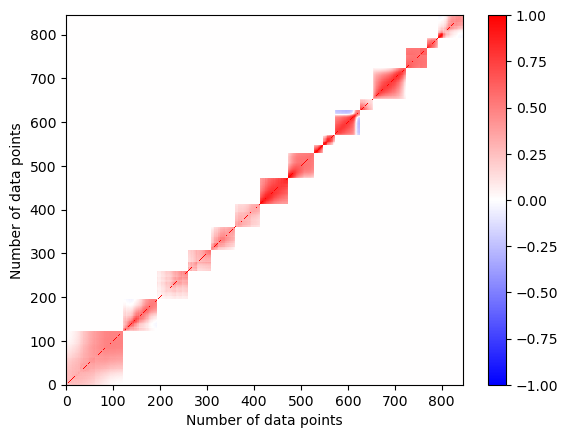

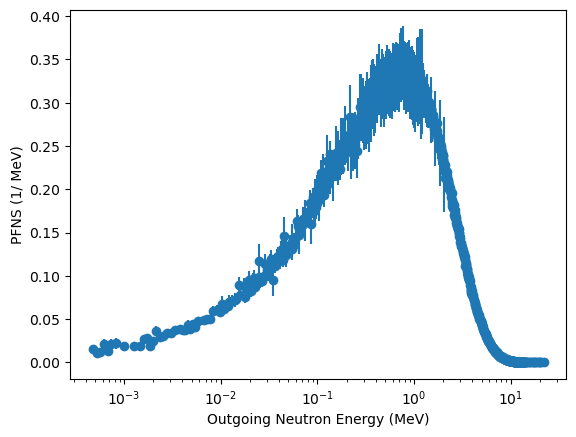

In [15]:
Data = homedir+'DataBase_ForImpactAssessment_AfterAIMLknowledge_Upd20250908.json'
ExpInput = {'Code':"ARIADNE",'ReadOption':'json',\
              'Data':Data}
PriorInput = {'general_info': {'name': 'VIII0_noninformative',\
                               'isotope': array(['Cf-252']),\
                              'quantity': array(['nubar-prompt']), 'reaction':  array(['0,f'])},\
              'Data':{'mv':array([homedir+'PriorMVCf252PFNS_extendedgrid.dat']),\
              'cor':array([homedir+'PriorCorCf252PFNS_extendedgrid.dat'])}}


Eval.Evaluate(ExpInput,PriorInput,homedir,CommonGrid=False,PPPCorrection=True,Plot=False,MaxwRatioEval=False,LogEval=False,OutputFormat="ARIADNEtxt")

In [16]:
rename(homedir+'Eval_MvUncCf-2520,fnubar-promptGLS.dat',homedir+'Eval_MvUncCf252PFNS_AfterAIACHNEKnowledgePointwise_Upd20250908.dat')
rename(homedir+'Eval_CorCf-2520,fnubar-promptGLS.dat',homedir+'Eval_CorCf252PFNS_AfterAIACHNEKnowledgePointwise_Upd20250908.dat')

## Evaluate after AI/ML knoweldge from AIACHNE (LA-UR-25-30840, Figs. 4 and 5) - removed Kornilov data:
- Experimental database starts from AIACHNE Standards evaluation and includes AIACHNE experiment.
- The data have the following LA-UR number LA-UR-25-31736.
- Prior: uninformative prior.
- PPP: on   

------------------------------------
Experiments included in evaluation:
K.J. Kelly
['Blinov', 'Vitenko', 'Tuz', 'Kazarinov', 'Krisyuk']
['Blinov', 'Vitenko', 'Yurevich']
['Blinov', 'Vitenko', 'Yurevich']
['Blinov', 'Vitenko', 'Yurevich']
['Blinov', 'Vitenko', 'Yurevich']
['Bottger', 'Klein', 'Chalupka', 'Strohmaier']
['Boldeman', 'Clancy', 'Culley']
['Boytsov', 'Starostov']
['Boytsov', 'Starostov']
['Boytsov', 'Starostov']
['A.Chalupka', 'L.Malek', 'S.Tagesen', 'R.Boettger']
['A.Lajtai', 'P.P.Dyachenko', 'V.N.Kononov', 'E.A.Seregina']
['Maerten', 'Richter', 'Seeliger', 'Fromm', 'Boettger', 'Klein']
['Poenitz', 'Tamura']
------------------------------------

 All experimental data within prior grid.
-------------------------------------------
PPP execution, deviation of previous iteration from current iteration prior (should converge with number of iterations): [1.00813373 1.00818959 1.00747982 1.00664304 1.00578782 1.00495652
 1.00419573 1.00340854 1.00245232 1.00042087 0.99832274 0.9

['/Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Cf-252/PFNS_EvaluationImpactAssessment/Eval_MvUncCf-2520,fnubar-promptGLS.dat',
 '/Users/dneudecker/Documents/Codes/ARIADNE-github/Examples/Cf-252/PFNS_EvaluationImpactAssessment/Eval_CorCf-2520,fnubar-promptGLS.dat']

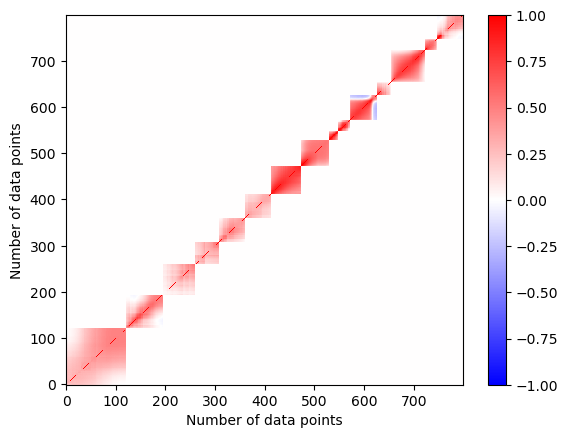

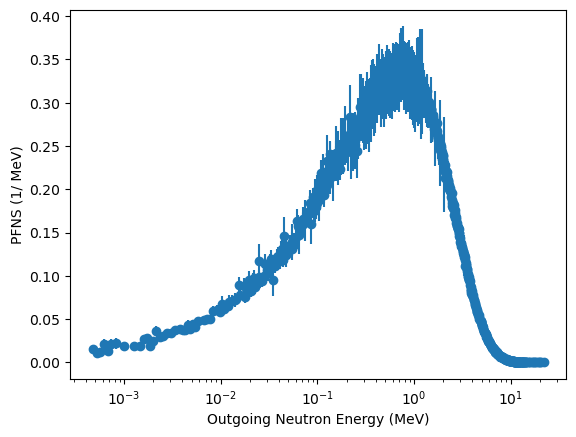

In [18]:
Data = homedir+'DataBase_ForImpactAssessment_AfterAIMLknowledge_Upd20250908_noKornilov.json'
ExpInput = {'Code':"ARIADNE",'ReadOption':'json',\
              'Data':Data}
PriorInput = {'general_info': {'name': 'VIII0_noninformative',\
                               'isotope': array(['Cf-252']),\
                              'quantity': array(['nubar-prompt']), 'reaction':  array(['0,f'])},\
              'Data':{'mv':array([homedir+'PriorMVCf252PFNS_extendedgrid.dat']),\
              'cor':array([homedir+'PriorCorCf252PFNS_extendedgrid.dat'])}}

Eval.Evaluate(ExpInput,PriorInput,homedir,CommonGrid=False,PPPCorrection=True,Plot=False,MaxwRatioEval=False,LogEval=False,OutputFormat="ARIADNEtxt")

In [19]:
rename(homedir+'Eval_MvUncCf-2520,fnubar-promptGLS.dat',homedir+'Eval_MvUncCf252PFNS_AfterAIACHNEKnowledgePointwise_Upd20250908_noKornilov.dat')
rename(homedir+'Eval_CorCf-2520,fnubar-promptGLS.dat',homedir+'Eval_CorCf252PFNS_AfterAIACHNEKnowledgePointwise_Upd20250908_noKornilov.dat')

## Producing Figs. 4 and 5 of LA-UR-25-30840:
- Most plotted data were produced above and released as part of LA-UR-25-31736.
- The Standards evaluation minus the AIACHNE experiment was released as part of LA-UR-25-20638.

In [21]:
data = loadtxt(homedir+'Eval_MvUncCf-2520,fnubar-promptGLS__Maerten60degonlyChalupka1datapointsrejectLA-UR-25-20638_finalaccepted.dat',skiprows=2)
E = data[:,0]
PFNSeval = data[:,1]
PFNSevalunc = data[:,2]
normf = 0.5*sum((PFNSeval[1:]+PFNSeval[:-1])*(E[1:]-E[:-1]))
PFNSeval = PFNSeval/normf
PFNSevalunc = PFNSevalunc/normf


data = loadtxt(homedir+'Eval_MvUncCf252PFNS_AfterAIACHNEKnowledgePointwise_Upd20250908.dat',skiprows=2)
E = data[:,0]
PFNSevalwithAIML = data[:,1]
PFNSevaluncwithAIML = data[:,2]
normf = 0.5*sum((PFNSevalwithAIML[1:]+PFNSevalwithAIML[:-1])*(E[1:]-E[:-1]))
PFNSevalwithAIML = PFNSevalwithAIML/normf
PFNSevaluncwithAIML = PFNSevaluncwithAIML/normf
normf = 0.5*sum((PFNSevalwithAIML[1:]+PFNSevalwithAIML[:-1])*(E[1:]-E[:-1]))

data = loadtxt(homedir+'Eval_MvUncCf252PFNS_BeforeAIACHNEKnowledgePointwise_RemoveKnitter.dat',skiprows=2)
E = data[:,0]
PFNSevalwithoutAIMLKn = data[:,1]
PFNSevaluncwithoutAIMLKn = data[:,2]
normf = 0.5*sum((PFNSevalwithoutAIMLKn[1:]+PFNSevalwithoutAIMLKn[:-1])*(E[1:]-E[:-1]))
PFNSevalwithoutAIMLKn = PFNSevalwithoutAIMLKn/normf
PFNSevaluncwithoutAIMLKn = PFNSevaluncwithoutAIMLKn/normf
normf = 0.5*sum((PFNSevalwithoutAIMLKn[1:]+PFNSevalwithoutAIMLKn[:-1])*(E[1:]-E[:-1]))

data = loadtxt(homedir+'Eval_MvUncCf252PFNS_AfterAIACHNEKnowledgePointwise_Upd20250908_noKornilov.dat',skiprows=2)
E = data[:,0]
PFNSevalwithoutAIMLKo = data[:,1]
PFNSevaluncwithoutAIMLKo = data[:,2]
normf = 0.5*sum((PFNSevalwithoutAIMLKo[1:]+PFNSevalwithoutAIMLKo[:-1])*(E[1:]-E[:-1]))
PFNSevalwithoutAIMLKo = PFNSevalwithoutAIMLKo/normf
PFNSevaluncwithoutAIMLKo = PFNSevaluncwithoutAIMLKo/normf
normf = 0.5*sum((PFNSevalwithoutAIMLKo[1:]+PFNSevalwithoutAIMLKo[:-1])*(E[1:]-E[:-1]))

data = loadtxt(homedir+'Eval_MvUncCf252PFNS_BeforeAIACHNEKnowledgePointwise_Final.dat',skiprows=2)
E = data[:,0]
PFNSevalwithoutAIML = data[:,1]
PFNSevaluncwithoutAIML = data[:,2]
normf = 0.5*sum((PFNSevalwithoutAIML[1:]+PFNSevalwithoutAIML[:-1])*(E[1:]-E[:-1]))
PFNSevalwithoutAIML = PFNSevalwithoutAIML/normf
PFNSevaluncwithoutAIML = PFNSevaluncwithoutAIML/normf
normf = 0.5*sum((PFNSevalwithoutAIML[1:]+PFNSevalwithoutAIML[:-1])*(E[1:]-E[:-1]))

data    = loadtxt(homedir+'AIACHNE_PartialUnc.dat')
EAIA    = data[:,0]
PFNSAIA = data[:,1]
normf   = norm(E,PFNSevalwithAIML,EAIA,PFNSAIA)
PFNSAIA = PFNSAIA * normf
UncAIA  = data[:,2]*PFNSAIA/100.0

cffile = homedir+'PriorMVCf252PFNS_extendedgrid.dat'

dat = loadtxt(cffile)

EMan  = dat[:,0]
mvMan = dat[:,1]

Normalization factor: 1.0128546804745238


## Fig. 5, left-hand side of LA-UR-25-30840:

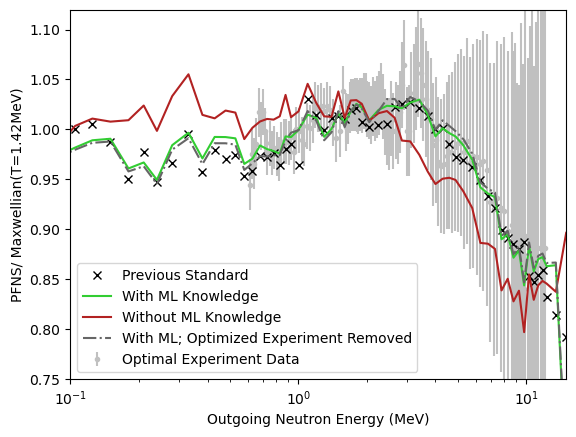

In [23]:
a = 0.1
b = 15.
plt.figure(2)
plt.xlabel('Outgoing Neutron Energy (MeV)')
plt.ylabel('PFNS/ Maxwellian(T=1.42MeV)')
plt.semilogx(EMan,mvMan/maxwt(EMan,1.42),'kx')
plt.semilogx(E,PFNSevalwithAIML/maxwt(E,1.42),'limegreen')
plt.semilogx(E,PFNSevalwithoutAIML/maxwt(E,1.42),color='firebrick')
plt.semilogx(E,PFNSeval/maxwt(E,1.42),'-.',color='0.4')
plt.errorbar(EAIA,PFNSAIA/maxwt(EAIA,1.42),UncAIA/maxwt(EAIA,1.42),color='silver',fmt='.',zorder=1)

plt.xlim([a,b])
plt.ylim([0.75,1.12])
plt.legend(['Previous Standard','With ML Knowledge','Without ML Knowledge','With ML; Optimized Experiment Removed','Optimal Experiment Data'],loc=3)
plt.savefig(homedir+'ImpactOptExp_v2.pdf')
plt.show()

## Fig. 5, right-hand side of LA-UR-25-30840:

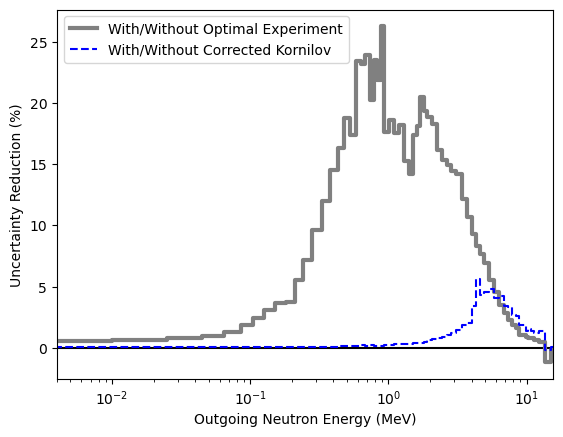

In [25]:
plt.xlabel('Outgoing Neutron Energy (MeV)')
plt.ylabel('Uncertainty Reduction (%)')
plt.xlim([0.004,15.5])
plt.semilogx(E,100-100.0*PFNSevaluncwithAIML/PFNSevalunc,drawstyle='steps',color='grey',linewidth=3.0)
plt.semilogx(E,100-100.0*PFNSevaluncwithAIML/PFNSevaluncwithoutAIMLKo,drawstyle='steps',color='b',linestyle='dashed')
plt.semilogx(E,zeros(shape(PFNSevaluncwithAIML)[0],dtype=float),drawstyle='steps',color='k',zorder=1)
plt.legend(['With/Without Optimal Experiment','With/Without Corrected Kornilov'],loc=2)
plt.savefig(homedir+'ImpactOptExp_Unc.pdf')

## Fig. 4, left-hand side of LA-UR-25-30840:

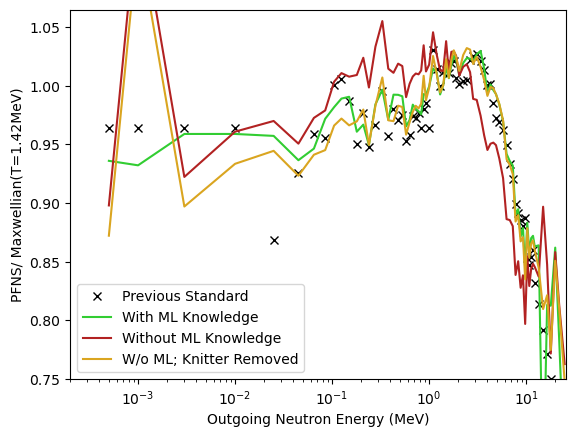

In [27]:
a = 0.0002
b = 26.
plt.figure(2)
#plt.ylim([0.6,1.2])
plt.xlabel('Outgoing Neutron Energy (MeV)')
plt.ylabel('PFNS/ Maxwellian(T=1.42MeV)')
plt.semilogx(EMan,mvMan/maxwt(EMan,1.42),'kx')
plt.semilogx(E,PFNSevalwithAIML/maxwt(E,1.42),'limegreen')
plt.semilogx(E,PFNSevalwithoutAIML/maxwt(E,1.42),'firebrick')
plt.semilogx(E,PFNSevalwithoutAIMLKn/maxwt(E,1.42),'goldenrod')
plt.xlim([a,b])
plt.ylim([0.75,1.065])
plt.legend(['Previous Standard','With ML Knowledge','Without ML Knowledge','W/o ML; Knitter Removed','With AI/ML Remove Kornilov'],loc=3)
plt.savefig(homedir+'ImpactKnitterMv.pdf')
plt.show()

## Fig. 4, right-hand side of LA-UR-25-30840:

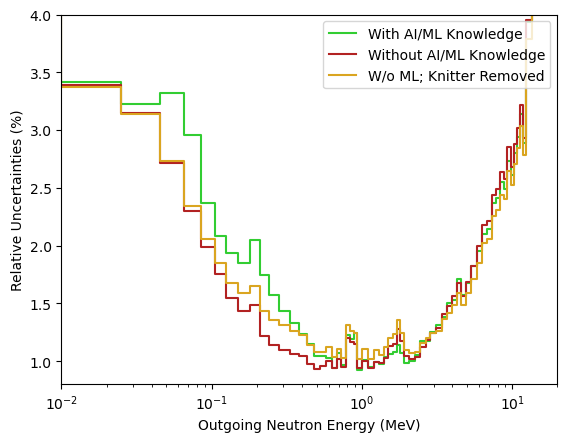

In [29]:
plt.xlabel('Outgoing Neutron Energy (MeV)')
plt.ylabel('Relative Uncertainties (%)')
plt.ylim([0.8,4.0])
plt.xlim([0.01,20.0])
plt.semilogx(E,PFNSevaluncwithAIML,color='limegreen',drawstyle='steps')
plt.semilogx(E,PFNSevaluncwithoutAIML,color='firebrick',drawstyle='steps')
plt.semilogx(E,PFNSevaluncwithoutAIMLKn,color='goldenrod',drawstyle='steps')
plt.legend(['With AI/ML Knowledge','Without AI/ML Knowledge','W/o ML; Knitter Removed'],loc=1)
plt.show()